# Toward error vs. SNR: first working slice

**Goal:** plot **pulse reconstruction error vs. trace SNR** (test set, after training).

**This notebook:** supervised **train + validation + test** on simulated FROG traces.

- **Model:** imported from an **external module** (not defined here).
- **Noise on traces:** AWGN on FROG intensity with **amplitude** SNR in dB ($\rho=\bar I/\sigma_n$, $\rho=10^{\mathrm{SNR}_{\mathrm{dB}}/20}$; see **Trace SNR, AWGN, and SNR$_1$** in `trace_noise.py`).
- **Forward physics:** `FROGNet` from `frognet.py`.

Training uses random SNR per batch; validation uses a fixed `VAL_SNR_DB` and plots L1 vs. epoch. After training: SNR sweep on **test** and error-vs-SNR plot (secondary x-axis: equivalent pulse count $N$ from SNR$_1$).


**Code cell below:**
- Imports (PyTorch, plotting, data loaders).
- External **model** (`TraceToPulseCNN`) and **noise** (`add_trace_noise` from `trace_noise`).
- Project helpers: pulse generation + `FROGNet`.

In [1]:
from __future__ import annotations

from typing import Callable

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

from data_generation import generate_pulses_gaussian
from frognet import FROGNet

# --- External model (replace module/class as needed) ---
from frog_reconstruction_model import TraceToPulseCNN

# --- External trace noise (replace module/function as needed; not required to be utils.py) ---
from trace_noise import add_trace_noise_awgn

import importlib
import pulse_metrics
importlib.reload(pulse_metrics)  # pick up edits without kernel restart
from pulse_metrics import l1_packed_per_pulse_torch, pulse_packed_l1_loss_torch

add_trace_noise: Callable[[torch.Tensor, float], torch.Tensor] = add_trace_noise_awgn

**Code cell below:**
- `DEVICE`, random seed, grid size `N`.
- Dataset sizes (train / val / **test**), batch size, epochs, learning rate.
- Train SNR range, fixed validation SNR (`VAL_SNR_DB`), SNR sweep grid, checkpoint path.

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

N = 64  # time samples; FROG trace [B, N, N] when num_delay_steps == N

# Pulse synthesis — same as pulses_generator_NB.ipynb
T_TOTAL = 250.0  # attoseconds, full time window
DT = T_TOTAL / N
SIGMA_OMEGA = 0.05 * (2 * np.pi / DT)
SIGMA_GAUSS = 1.6
PHASE_SCALE = np.pi
N_TRAIN = 2048
N_VAL = 512
N_TEST = 512
BATCH_SIZE = 64
EPOCHS = 15
LR = 1e-3

TRAIN_SNR_DB_RANGE = (0.0, 30.0)
VAL_SNR_DB = 15.0
SNR_SWEEP_DB = np.arange(-10.0, 31.0, 5.0)  # -10, -5, 0, 5, ..., 30 dB
CHECKPOINT_PATH = "checkpoints/trace_to_pulse_cnn.pt"

PCGPA_MAXITER = 200
PCGPA_N_RESTARTS = 3
PCGPA_N_TEST = 32  # lower (e.g. 8) for quick sweeps; N_TEST for full paper run
RUN_PCGPA_SWEEP = True
FORCE_RECOMPUTE_PCGPA = True  # set False to load checkpoints/pcgpa_snr_sweep.npz
PCGPA_SWEEP_CACHE = "checkpoints/pcgpa_snr_sweep.npz"

print("DEVICE:", DEVICE)

DEVICE: cpu


## Trace SNR, AWGN, and the single-pulse reference SNR$_1$

This notebook uses **amplitude SNR** (not power SNR) on FROG **intensity** traces. Two related quantities appear:

1. **Trace SNR** — sets AWGN on simulated traces during training and evaluation (`trace_noise.py`).
2. **SNR$_1$** — single-pulse reference for mapping trace SNR to an **equivalent pulse count** $N_{\mathrm{eq}}$ on secondary plots (`snr_db_to_equivalent_n_pulses` in `pulse_metrics.py`).

---

### 1. Signal and noise on one trace pixel

**Clean trace.** For each pulse, $E(t)$ is propagated through `FROGNet` to an intensity trace

$$
I_{\mathrm{clean}}(\omega,\tau) = \left| \tilde{G}(\omega,\tau) \right|^2
$$

(non-negative SHG-FROG intensity; stored as `I_train`, `I_val`, `I_test`).

**Signal amplitude per pixel.** At every pixel the **signal** is the FROG **intensity** $I$ (not $\sqrt{I}$). The scalar level used for SNR is the **mean over all** $\omega$ and $\tau$ samples in that trace:

$$
\bar I \equiv \mathrm{mean}\bigl(I_{\mathrm{clean}}\bigr).
$$

**SNR is an amplitude ratio**, not a power ratio:

$$
\rho \equiv \mathrm{SNR}_{\mathrm{lin}} = \frac{\bar I}{\sigma_n},
$$

where $\sigma_n$ is the **standard deviation** of the additive noise on each pixel (not $\sigma_n^2$).

---

### 2. Decibels $\leftrightarrow$ linear SNR (amplitude)

$$
\mathrm{SNR}_{\mathrm{dB}} = 20 \log_{10}(\rho)
\qquad\Leftrightarrow\qquad
\rho = 10^{\mathrm{SNR}_{\mathrm{dB}}/20}.
$$

(`snr_db_to_linear` / `snr_linear_to_db` in `trace_noise.py`.)

- Training draws $\mathrm{SNR}_{\mathrm{dB}}$ uniformly in `TRAIN_SNR_DB_RANGE`, then uses $\rho = 10^{\mathrm{SNR}_{\mathrm{dB}}/20}$ inside `add_trace_noise_awgn`.
- Sweeps use fixed values in `SNR_SWEEP_DB`; each point applies the same dB $\to$ linear conversion before adding noise.

---

### 3. AWGN on the trace (`trace_noise.py`)

For a requested $\mathrm{SNR}_{\mathrm{dB}}$:

$$
\rho = 10^{\mathrm{SNR}_{\mathrm{dB}}/20},
\qquad
\sigma_n = \frac{\bar I}{\rho}.
$$

**Additive WGN** — independent Gaussian noise on every trace pixel:

$$
n \sim \mathcal{N}(0,\,\sigma_n^2),
\qquad
I_{\mathrm{noisy}} = I_{\mathrm{clean}} + n.
$$

(`add_trace_noise_awgn`: `noise = randn_like(I) * sigma_n`.)

**Note:** $\bar I$ depends on the simulated pulse and FROG forward model; it is **not** fixed to the reference $A_{s1}$ below. SNR$_1$ enters only when mapping trace SNR to $N_{\mathrm{eq}}$, not when drawing AWGN on a given trace.

---

### 4. $N$ measurements: scaling of mean signal and noise

Average over **$N$ independent measurements** (each trace pixel carries FROG intensity; averages are over pixels **and** over the $N$ shots):

| Quantity | Single measurement | $N$ averaged measurements |
|----------|-------------------|---------------------------|
| Mean signal (over pixels) | $\bar I_1$ | $\bar I_N = N\,\bar I_1$ |
| Mean noise std (over pixels) | $\sigma_1$ | $\sigma_N = \sqrt{N}\,\sigma_1$ |

Therefore the **linear amplitude SNR** scales as

$$
\rho_N = \frac{\bar I_N}{\sigma_N}
= \frac{N\,\bar I_1}{\sqrt{N}\,\sigma_1}
= \sqrt{N}\,\rho_1.
$$

Equivalently, the number of pulses is the ratio of **squared** linear SNRs:

$$
N = \left(\frac{\rho_N}{\rho_1}\right)^2.
$$

---

### 5. Single-pulse reference SNR$_1$

Defaults in `snr_db_to_equivalent_n_pulses`:

- **Photons per pulse:** $N_{\mathrm{ph}} = 10^{12}$ (`photons_per_pulse`)
- **Process efficiency:** $\eta = 10^{-12}$ (`efficiency`)

Reference **signal amplitude** (mean FROG intensity scale for one pulse):

$$
A_{s1} = \eta \times N_{\mathrm{ph}} = 10^{-12} \times 10^{12} = 1.
$$

Reference **noise standard deviation** per pixel (one pulse):

$$
\sigma_{n1} = 80 \times A_{s1} = 80
\quad\text{(`pn1_over_ps1 = 80`).}
$$

**Single-pulse linear SNR:**

$$
\rho_1 \equiv \mathrm{SNR}_1 = \frac{A_{s1}}{\sigma_{n1}} = \frac{1}{80},
$$

i.e. about **−38.1 dB** ($20\log_{10}(1/80)$).

| Quantity | Value | Code parameter |
|----------|-------|----------------|
| $N_{\mathrm{ph}}$ | $10^{12}$ photons / pulse | `photons_per_pulse` |
| $\eta$ | $10^{-12}$ | `efficiency` |
| $A_{s1}=\eta N_{\mathrm{ph}}$ | $1$ | — |
| $\sigma_{n1}$ | $80\,A_{s1}$ | `pn1_over_ps1 = 80` |
| $\rho_1 = A_{s1}/\sigma_{n1}$ | $1/80$ | — |

**Equivalent pulse count** (secondary plots): for trace SNR in dB, convert to $\rho_N = 10^{\mathrm{SNR}_{\mathrm{dB}}/20}$ and invert

$$
\rho_N = \mathrm{SNR}_1 \sqrt{N_{\mathrm{eq}}}
\quad\Rightarrow\quad
N_{\mathrm{eq}} = \left(\frac{\rho_N}{\mathrm{SNR}_1}\right)^2
= \left(\frac{10^{\mathrm{SNR}_{\mathrm{dB}}/20}}{\mathrm{SNR}_1}\right)^2.
$$

(`snr_db_to_equivalent_n_pulses` in `pulse_metrics.py`.)


**Code cell below:**
- Generate synthetic pulses; pack to `[B, 2N]`.
- Forward through `FROGNet` → clean traces `I_train`, `I_val`, `I_test`.
- Build train / val / **test** `DataLoader`s (noise added later in the loop).

In [3]:
def pack_pulses_complex(pulses_c: np.ndarray) -> torch.Tensor:
    """[B, N] complex -> [B, 2N] float32 (Re then Im)."""
    r = np.real(pulses_c).astype(np.float32)
    im = np.imag(pulses_c).astype(np.float32)
    return torch.from_numpy(np.concatenate([r, im], axis=-1))


p_train_c, _, _, _ = generate_pulses_gaussian(
    n_pulses=N_TRAIN,
    dt=DT,
    sigma_omega=SIGMA_OMEGA,
    num_points=N,
    sigma=SIGMA_GAUSS,
    phase_scale=PHASE_SCALE,
    seed=SEED,
)
p_val_c, _, _, _ = generate_pulses_gaussian(
    n_pulses=N_VAL,
    dt=DT,
    sigma_omega=SIGMA_OMEGA,
    num_points=N,
    sigma=SIGMA_GAUSS,
    phase_scale=PHASE_SCALE,
    seed=SEED + 1,
)
p_test_c, _, t_vec, w_vec = generate_pulses_gaussian(
    n_pulses=N_TEST,
    dt=DT,
    sigma_omega=SIGMA_OMEGA,
    num_points=N,
    sigma=SIGMA_GAUSS,
    phase_scale=PHASE_SCALE,
    seed=SEED + 2,
)

E_train = pack_pulses_complex(p_train_c).to(DEVICE)
E_val = pack_pulses_complex(p_val_c).to(DEVICE)
E_test = pack_pulses_complex(p_test_c).to(DEVICE)

frog = FROGNet(num_delay_steps=N).to(DEVICE)
frog.eval()

with torch.no_grad():
    I_train = frog(E_train)
    I_val = frog(E_val)
    I_test = frog(E_test)

train_loader = DataLoader(
    TensorDataset(I_train, E_train), batch_size=BATCH_SIZE, shuffle=True, drop_last=False
)
val_loader = DataLoader(
    TensorDataset(I_val, E_val), batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)
test_loader = DataLoader(
    TensorDataset(I_test, E_test), batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

print("E_train", tuple(E_train.shape), "I_train", tuple(I_train.shape))
print("E_test", tuple(E_test.shape), "I_test", tuple(I_test.shape))

E_train (2048, 128) I_train (2048, 64, 64)
E_test (512, 128) I_test (512, 64, 64)


**Code cell below:**
- Instantiate imported `TraceToPulseCNN` on `DEVICE`.
- One dummy forward (for `LazyLinear`); print parameter count.

In [4]:
model = TraceToPulseCNN(out_dim=2 * N).to(DEVICE)
_ = model(I_train[:2].unsqueeze(1))
print("Parameters:", sum(p.numel() for p in model.parameters()))

Parameters: 4266208


**Code cell below:**
- Train loop: random $\mathrm{SNR}_{\mathrm{dB}}$ → convert to linear → `add_trace_noise` (AWGN on trace; see **Trace SNR, AWGN, and SNR$_1$**) → model → L1 loss → Adam.
- Val loop each epoch: fixed `VAL_SNR_DB`, mean L1 on val set.
- Print train/val loss per epoch; store curves in lists.

In [5]:
# ‖ΔE‖₁ per pulse (sum over 2N), mean over batch — not mean over 2N
criterion = pulse_packed_l1_loss_torch
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses: list[float] = []
val_l1_pulses: list[float] = []

for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    n_seen = 0
    for I_clean, E_true in train_loader:
        snr = float(np.random.uniform(TRAIN_SNR_DB_RANGE[0], TRAIN_SNR_DB_RANGE[1]))
        I_noisy = add_trace_noise(I_clean, snr)
        x = I_noisy.unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)
        E_pred = model(x)
        loss = criterion(E_pred, E_true)
        loss.backward()
        optimizer.step()

        b = I_clean.shape[0]
        running += loss.item() * b
        n_seen += b

    train_losses.append(running / max(n_seen, 1))

    model.eval()
    vsum, vcount = 0.0, 0
    with torch.no_grad():
        for I_clean, E_true in val_loader:
            I_noisy = add_trace_noise(I_clean, VAL_SNR_DB)
            E_pred = model(I_noisy.unsqueeze(1))
            vloss = criterion(E_pred, E_true)
            b = I_clean.shape[0]
            vsum += vloss.item() * b
            vcount += b
    val_l1_pulses.append(vsum / max(vcount, 1))

    print(
        f"epoch {epoch+1:03d}/{EPOCHS}  train_L1={train_losses[-1]:.5f}  "
        f"val_L1@{VAL_SNR_DB:.1f}dB={val_l1_pulses[-1]:.5f}"
    )

print("Done.")

epoch 001/15  train_L1=5.93632  val_L1@15.0dB=4.96246
epoch 002/15  train_L1=4.95371  val_L1@15.0dB=4.85819
epoch 003/15  train_L1=4.79955  val_L1@15.0dB=4.56986
epoch 004/15  train_L1=4.45121  val_L1@15.0dB=4.23206
epoch 005/15  train_L1=4.21746  val_L1@15.0dB=4.07338
epoch 006/15  train_L1=4.07076  val_L1@15.0dB=3.95119
epoch 007/15  train_L1=3.96591  val_L1@15.0dB=3.88003
epoch 008/15  train_L1=3.88848  val_L1@15.0dB=3.84789
epoch 009/15  train_L1=3.84375  val_L1@15.0dB=3.78643
epoch 010/15  train_L1=3.78084  val_L1@15.0dB=3.75363
epoch 011/15  train_L1=3.74366  val_L1@15.0dB=3.74074
epoch 012/15  train_L1=3.70832  val_L1@15.0dB=3.69124
epoch 013/15  train_L1=3.67416  val_L1@15.0dB=3.67034
epoch 014/15  train_L1=3.63991  val_L1@15.0dB=3.64639
epoch 015/15  train_L1=3.60911  val_L1@15.0dB=3.64567
Done.


**Code cell below:**
- Plot **train** and **val** mean L1 vs. epoch on the **same axes**.
- Legend + grid; `plt.show()`.

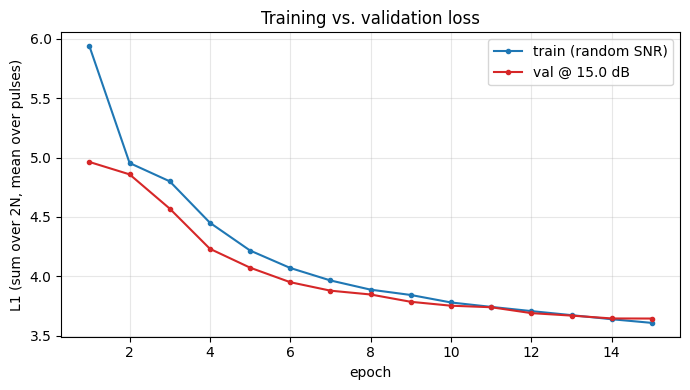

In [6]:
epochs_axis = np.arange(1, len(train_losses) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_axis, train_losses, "-o", markersize=3, label="train (random SNR)")
plt.plot(
    epochs_axis,
    val_l1_pulses,
    "-o",
    color="tab:red",
    markersize=3,
    label=f"val @ {VAL_SNR_DB:.1f} dB",
)
plt.xlabel("epoch")
plt.ylabel("L1 (sum over 2N, mean over pulses)")
plt.title("Training vs. validation loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Code cell below** (run after training — do not re-run the train cell):

- `l1_stats_at_snr` — per test pulse: fixed-SNR noise → predict → L1; return **mean ± std** over pulses.
- Save model weights to `CHECKPOINT_PATH`.
- Loop over `SNR_SWEEP_DB` (−10…30 dB); at each SNR, AWGN on traces per **Trace SNR, AWGN, and SNR$_1$**; print mean ± std L1.
- Plot: X = trace SNR (dB), Y = mean L1 with **error bars** (±1 std over test pulses).

Saved: D:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\trace_to_pulse_cnn.pt
test L1 @ -10.0 dB = 3.92278 ± 1.60152
test L1 @ -5.0 dB = 3.68185 ± 1.73633
test L1 @ 0.0 dB = 3.60371 ± 1.76321
test L1 @ 5.0 dB = 3.59079 ± 1.77566
test L1 @ 10.0 dB = 3.58384 ± 1.77986
test L1 @ 15.0 dB = 3.58154 ± 1.78231
test L1 @ 20.0 dB = 3.58230 ± 1.78315
test L1 @ 25.0 dB = 3.58158 ± 1.78288
test L1 @ 30.0 dB = 3.58168 ± 1.78340


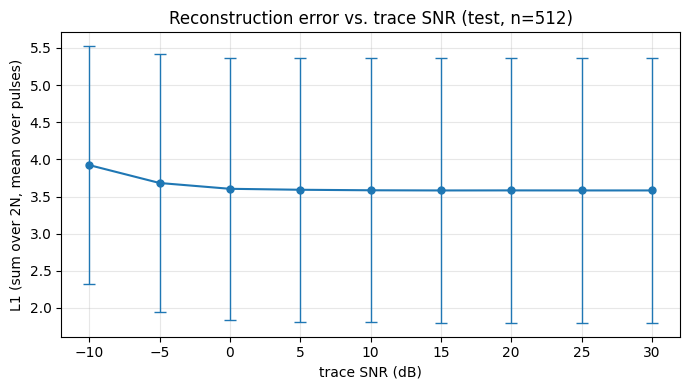

In [7]:
from pathlib import Path


def l1_stats_at_snr(loader: DataLoader, snr_db: float) -> tuple[float, float]:
    """Mean and std of per-pulse L1 (mean |error| over Re/Im samples)."""
    model.eval()
    per_pulse: list[float] = []
    with torch.no_grad():
        for I_clean, E_true in loader:
            I_noisy = add_trace_noise(I_clean, snr_db)
            E_pred = model(I_noisy.unsqueeze(1))
            per_pulse.extend(l1_packed_per_pulse_torch(E_pred, E_true).cpu().tolist())
    arr = np.asarray(per_pulse, dtype=np.float64)
    return float(arr.mean()), float(arr.std(ddof=0))


ckpt_path = Path(CHECKPOINT_PATH)
ckpt_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "N": N,
        "train_snr_db_range": TRAIN_SNR_DB_RANGE,
    },
    ckpt_path,
)
print("Saved:", ckpt_path.resolve())

test_l1_mean: list[float] = []
test_l1_std: list[float] = []
for snr_db in SNR_SWEEP_DB:
    mean_err, std_err = l1_stats_at_snr(test_loader, float(snr_db))
    test_l1_mean.append(mean_err)
    test_l1_std.append(std_err)
    print(f"test L1 @ {snr_db:.1f} dB = {mean_err:.5f} ± {std_err:.5f}")

plt.figure(figsize=(7, 4))
plt.errorbar(
    SNR_SWEEP_DB,
    test_l1_mean,
    yerr=test_l1_std,
    fmt="-o",
    markersize=5,
    capsize=4,
    elinewidth=1,
)
plt.xlabel("trace SNR (dB)")
plt.ylabel("L1 (sum over 2N, mean over pulses)")
plt.title(f"Reconstruction error vs. trace SNR (test, n={N_TEST})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
model

TraceToPulseCNN(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU(inplace=True)
    (4): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
    (5): ReLU(inplace=True)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=8192, out_features=512, bias=True)
    (8): ReLU(inplace=True)
    (9): Linear(in_features=512, out_features=128, bias=True)
  )
)

## PCGPA baseline (classical)

`pcgpa_reconstruct.py` runs PCGPA on the **same** FROGNet traces `[N_ω, N_τ]` (random initial guess; no ground-truth spectrum). Noisy traces use the same AWGN / dB $\to$ linear rules as the CNN (**Trace SNR, AWGN, and SNR$_1$**). SNR sweep: **four** plots vs trace SNR (dB) and **four** vs $N_{\mathrm{eq}}$ from $\mathrm{SNR}_N=\mathrm{SNR}_1\sqrt{N_{\mathrm{eq}}}$. Metrics: **SIMILARITY_ERROR** and L1. **PCGPA** always uses best ambiguity; **CNN** raw vs best ambiguity. Above: overlay $|E(t)|$ @ 30 dB.

Requires:
- `vendor/pypret`: `git clone --depth 1 https://github.com/ncgeib/pypret.git vendor/pypret`
- Python packages (in your notebook venv): `pip install h5py scipy`

**Run all cells above first** (imports → hyperparameters → data/`I_test` → model → training or load checkpoint). PCGPA cells use `I_test`, `E_test`, `SEED`, `PCGPA_MAXITER`, `add_trace_noise`.

In [9]:
import os

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import pcgpa_reconstruct
from pulse_metrics import best_delta_e_ambiguity, unpack_packed_field

pcgpa_reconstruct = pcgpa_reconstruct.reload_from_disk()
print("pcgpa_reconstruct:", pcgpa_reconstruct.__file__)
reconstruct_pcgpa = pcgpa_reconstruct.reconstruct_pcgpa

_pcgpa_prereq = ("I_test", "E_test", "SEED", "PCGPA_MAXITER", "add_trace_noise")
_missing = [n for n in _pcgpa_prereq if n not in globals()]
if _missing:
    raise RuntimeError(
        "Run earlier notebook cells first (data + hyperparameters). Missing: "
        + ", ".join(_missing)
    )

# --- smoke test: one test pulse, clean trace ---
_i = 0
_i_clean = I_test[_i].cpu().numpy()
_e_ref = unpack_packed_field(E_test[_i].cpu().numpy())
_e_pcgpa = reconstruct_pcgpa(
    _i_clean,
    dt=DT,
    sigma_omega=SIGMA_OMEGA,
    maxiter=PCGPA_MAXITER,
    n_restarts=PCGPA_N_RESTARTS,
    rng=np.random.default_rng(SEED),
)
print(
    "PCGPA smoke (clean trace), best δE:",
    f"{best_delta_e_ambiguity(_e_pcgpa, _e_ref):.6f} rad",
)

_i_noisy = add_trace_noise(I_test[_i : _i + 1], 10.0).squeeze(0).cpu().numpy()
_e_pcgpa_noisy = reconstruct_pcgpa(
    _i_noisy,
    dt=DT,
    sigma_omega=SIGMA_OMEGA,
    maxiter=PCGPA_MAXITER,
    n_restarts=PCGPA_N_RESTARTS,
    rng=np.random.default_rng(SEED + 1),
)
print(
    "PCGPA smoke (10 dB), best δE:",
    f"{best_delta_e_ambiguity(_e_pcgpa_noisy, _e_ref):.6f} rad",
)

pcgpa_reconstruct: D:\Haim\Haim 3rd paper\Ultra-Fast project\src\pcgpa_reconstruct.py
PCGPA smoke (clean trace), best δE: 0.271063 rad
PCGPA smoke (10 dB), best δE: 0.280042 rad


## CNN vs. PCGPA: recovered vs. true pulse @ 30 dB

One test pulse @ 30 dB: two **2×2** figures (CNN vs. PCGPA, $|E|$ + phase) — **best L1** (`best_l1_ambiguity_field`) and **best δE** (`best_ambiguity_field`); then clean/noisy SHG-FROG trace. Printed metrics match the plotted aligned fields.

Running PCGPA @ 30 dB (maxiter=200, restarts=3) …
L1 @ 30 dB, pulse 0: CNN raw=3.37402  CNN L1-best=3.67371  PCGPA L1-best=1.88542
δE @ 30 dB, pulse 0: CNN δE-best=0.4322 rad  PCGPA δE-best=0.2198 rad


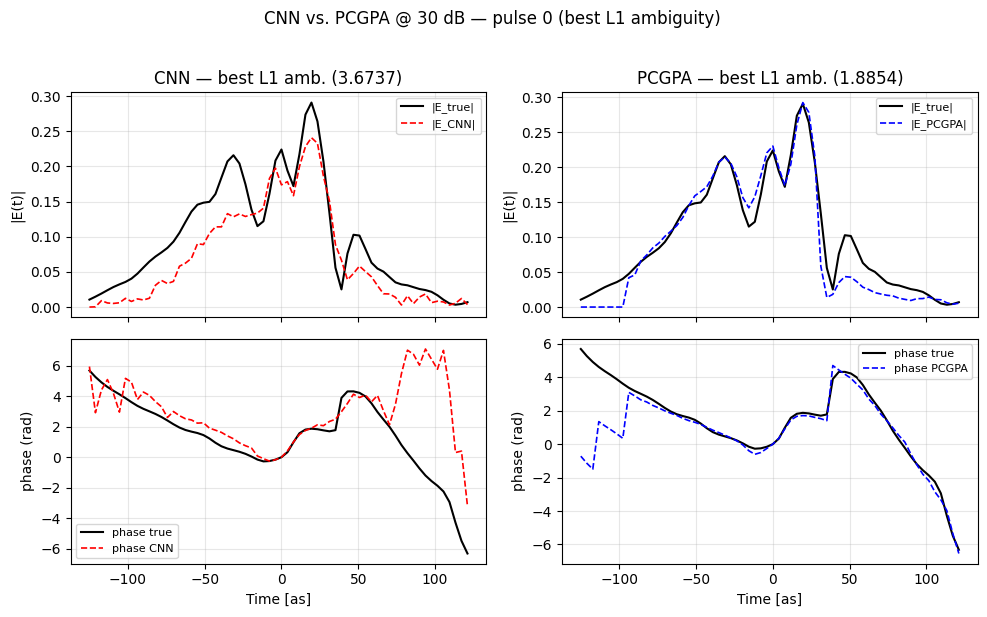

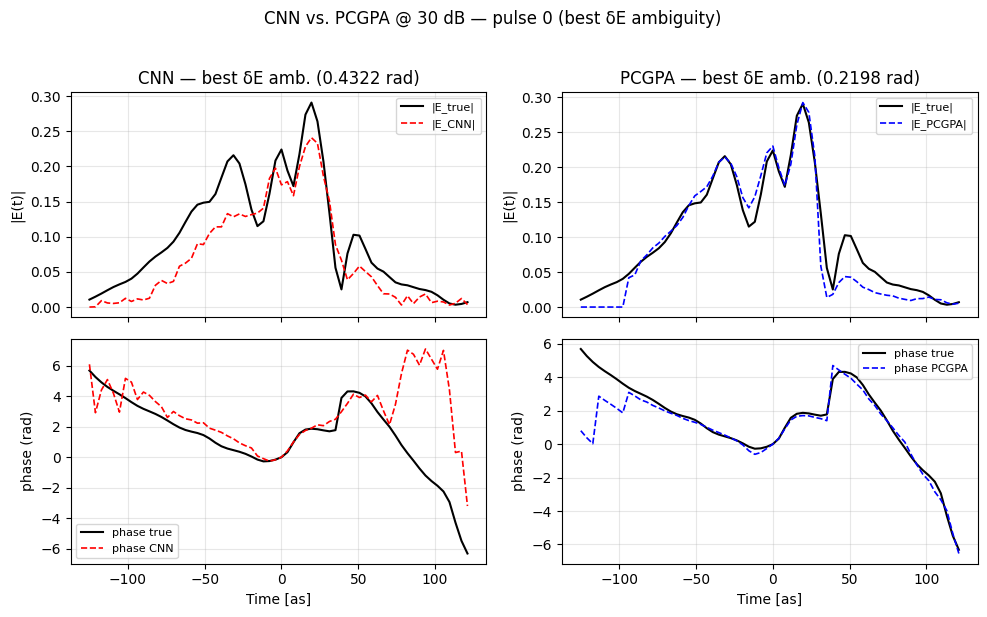

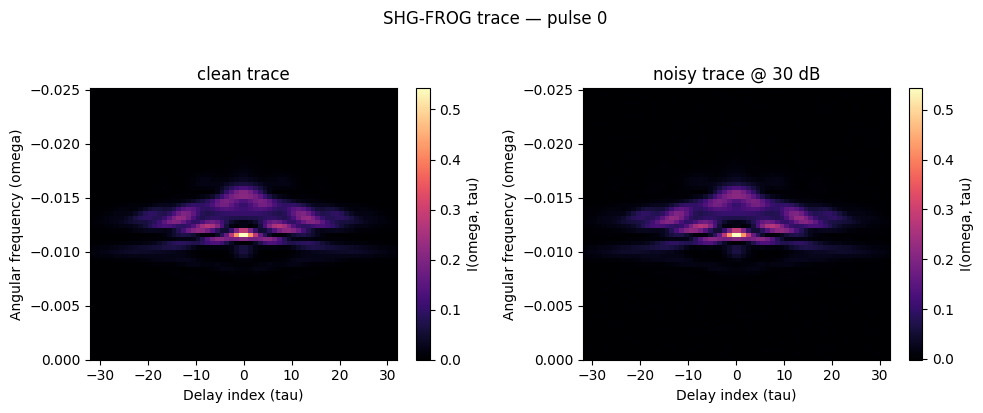

In [10]:
import importlib
import os

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import pcgpa_reconstruct
import pulse_metrics

importlib.reload(pulse_metrics)
from pulse_metrics import (
    best_ambiguity_field,
    best_l1_ambiguity_field,
    delta_e_numpy,
    l1_packed_mae,
    packed_batch_to_complex,
    prepare_frog_trace_for_plot,
    unpack_packed_field,
    unwrap_phases_for_overlay,
)

_pcgpa_mod = pcgpa_reconstruct.reload_from_disk()
reconstruct_pcgpa = _pcgpa_mod.reconstruct_pcgpa
_pcgpa_rng_for_pulse = _pcgpa_mod._pcgpa_rng_for_pulse

_PLOT_SNR_DB = 30.0
_plot_i = 0

model.eval()
with torch.no_grad():
    I_clean_1 = I_test[_plot_i : _plot_i + 1]
    I_n = add_trace_noise(I_clean_1, _PLOT_SNR_DB)
    E_pred = model(I_n.unsqueeze(1))

_i_noisy_np = I_n.squeeze(0).cpu().numpy()
e_true = unpack_packed_field(E_test[_plot_i].cpu().numpy())
e_rec = packed_batch_to_complex(E_pred)[0]
e_rec_amb = best_l1_ambiguity_field(e_rec, e_true)
e_rec_de_amb = best_ambiguity_field(e_rec, e_true)

print(f"Running PCGPA @ {_PLOT_SNR_DB:.0f} dB (maxiter={PCGPA_MAXITER}, restarts={PCGPA_N_RESTARTS}) …")
e_pcgpa = reconstruct_pcgpa(
    _i_noisy_np,
    dt=DT,
    sigma_omega=SIGMA_OMEGA,
    maxiter=PCGPA_MAXITER,
    n_restarts=PCGPA_N_RESTARTS,
    rng=_pcgpa_rng_for_pulse(SEED, _plot_i, _PLOT_SNR_DB),
)
e_pcgpa_amb = best_l1_ambiguity_field(e_pcgpa, e_true)
e_pcgpa_de_amb = best_ambiguity_field(e_pcgpa, e_true)
_e_true_packed = E_test[_plot_i].cpu().numpy()

_l1_raw = l1_packed_mae(e_rec, _e_true_packed, use_best_ambiguity=False)
_l1_cnn = l1_packed_mae(e_rec_amb, _e_true_packed, use_best_ambiguity=False)
_l1_pcgpa = l1_packed_mae(e_pcgpa_amb, _e_true_packed, use_best_ambiguity=False)
_de_cnn = delta_e_numpy(e_rec_de_amb, e_true)
_de_pcgpa = delta_e_numpy(e_pcgpa_de_amb, e_true)
print(
    f"L1 @ {_PLOT_SNR_DB:.0f} dB, pulse {_plot_i}: "
    f"CNN raw={_l1_raw:.5f}  CNN L1-best={_l1_cnn:.5f}  PCGPA L1-best={_l1_pcgpa:.5f}"
)
print(
    f"δE @ {_PLOT_SNR_DB:.0f} dB, pulse {_plot_i}: "
    f"CNN δE-best={_de_cnn:.4f} rad  PCGPA δE-best={_de_pcgpa:.4f} rad"
)
t_axis = t_vec
_ph_true, _ = unwrap_phases_for_overlay(e_rec_amb, e_true)


def _plot_cnn_vs_pcgpa(fig, axes, e_cnn, e_pcgpa, *, metric: str, cnn_val: float, pcgpa_val: float):
    """2×2: |E| and phase for CNN vs PCGPA (shared true phase overlay)."""
    for col, e_r, color, name in (
        (0, e_cnn, "r", "CNN"),
        (1, e_pcgpa, "b", "PCGPA"),
    ):
        val = cnn_val if col == 0 else pcgpa_val
        unit = "" if metric == "L1" else " rad"
        axes[0, col].plot(t_axis, np.abs(e_true), "k-", lw=1.5, label="|E_true|")
        axes[0, col].plot(t_axis, np.abs(e_r), color + "--", lw=1.2, label=f"|E_{name}|")
        axes[0, col].set_title(f"{name} — best {metric} amb. ({val:.4f}{unit})")
        axes[0, col].set_ylabel("|E(t)|")
        axes[0, col].legend(fontsize=8)
        axes[0, col].grid(True, alpha=0.3)

        _, ph_rec = unwrap_phases_for_overlay(e_r, e_true)
        axes[1, col].plot(t_axis, _ph_true, "k-", lw=1.5, label="phase true")
        axes[1, col].plot(t_axis, ph_rec, color + "--", lw=1.2, label=f"phase {name}")
        axes[1, col].set_xlabel("Time [as]")
        axes[1, col].set_ylabel("phase (rad)")
        axes[1, col].legend(fontsize=8)
        axes[1, col].grid(True, alpha=0.3)

    fig.suptitle(
        f"CNN vs. PCGPA @ {_PLOT_SNR_DB:.0f} dB — pulse {_plot_i} (best {metric} ambiguity)",
        y=1.02,
    )


fig_l1, axes_l1 = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
_plot_cnn_vs_pcgpa(fig_l1, axes_l1, e_rec_amb, e_pcgpa_amb, metric="L1", cnn_val=_l1_cnn, pcgpa_val=_l1_pcgpa)
plt.tight_layout()
plt.show()

fig_de, axes_de = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
_plot_cnn_vs_pcgpa(fig_de, axes_de, e_rec_de_amb, e_pcgpa_de_amb, metric="δE", cnn_val=_de_cnn, pcgpa_val=_de_pcgpa)
plt.tight_layout()
plt.show()

# FROG trace (clean vs noisy @ plot SNR)
_i_clean_np = I_clean_1.squeeze(0).cpu().numpy()
_trace_clean, _tau_axis, _omega_plot = prepare_frog_trace_for_plot(
    _i_clean_np, omega_axis=w_vec
)
_trace_noisy, _, _ = prepare_frog_trace_for_plot(_i_noisy_np, omega_axis=w_vec)
_extent = [_tau_axis[0], _tau_axis[-1], _omega_plot[0], _omega_plot[-1]]
fig_tr, axes_tr = plt.subplots(1, 2, figsize=(10, 4))
for ax, tr, title in zip(
    axes_tr,
    (_trace_clean, _trace_noisy),
    ("clean trace", f"noisy trace @ {_PLOT_SNR_DB:.0f} dB"),
):
    im = ax.imshow(tr, origin="lower", aspect="auto", extent=_extent, cmap="magma")
    ax.set_title(title)
    ax.set_xlabel("Delay index (tau)")
    ax.set_ylabel("Angular frequency (omega)")
    fig_tr.colorbar(im, ax=ax, label="I(omega, tau)")
fig_tr.suptitle(f"SHG-FROG trace — pulse {_plot_i}", y=1.02)
plt.tight_layout()
plt.show()


**trace SNR (dB)** — see **Trace SNR, AWGN, and SNR$_1$** (earlier in this notebook). Summary: clean trace $I_{\mathrm{clean}}$ from `FROGNet`; $\bar I=\mathrm{mean}(I_{\mathrm{clean}})$; amplitude SNR $\rho=10^{\mathrm{SNR}_{\mathrm{dB}}/20}=\bar I/\sigma_n$; AWGN with $\sigma_n=\bar I/\rho$; $I_{\mathrm{noisy}}=I_{\mathrm{clean}}+n$, $n\sim\mathcal{N}(0,\sigma_n^2)$.

**equivalent pulse count $N_{\mathrm{eq}}$** — from the same trace SNR (dB $\to$ $\rho=10^{\mathrm{SNR}_{\mathrm{dB}}/20}$) and single-pulse $\rho_1=A_{s1}/\sigma_{n1}$ with $A_{s1}=\eta N_{\mathrm{ph}}$ ($=10^{-12}\times10^{12}$) and $\sigma_{n1}=80\,A_{s1}$:

$$
N_{\mathrm{eq}} = \left( \frac{\rho}{\rho_1} \right)^2
= \left( \frac{10^{\mathrm{SNR}_{\mathrm{dB}}/20}}{\rho_1} \right)^2,
\qquad
\rho_1 = \frac{A_{s1}}{\sigma_{n1}} = \frac{1}{80}
$$

Plots use a **logarithmic** $N_{\mathrm{eq}}$ axis (`snr_db_to_equivalent_n_pulses`).


d:\Haim\Haim 3rd paper\Ultra-Fast project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sweep — PCGPA n=32 (always best amb.), CNN n=512 (raw vs best amb.)
PCGPA: 288 reconstructions (9 SNR × 32 pulses, maxiter=200, restarts=3) — may take a long time on CPU


SNR sweep: 100%|██████████| 9/9 [07:25<00:00, 49.48s/it]

Saved PCGPA sweep to checkpoints\pcgpa_snr_sweep.npz
CNN SIMILARITY_ERROR: max |mean(raw) − mean(amb)| over SNR = 0.072590
CNN L1: max |mean(raw) − mean(amb)| over SNR = 1.095040


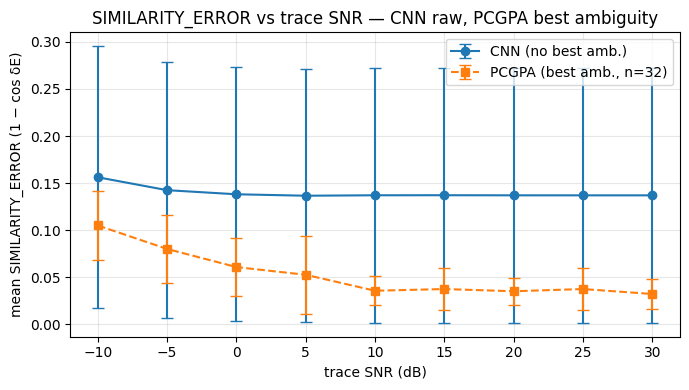

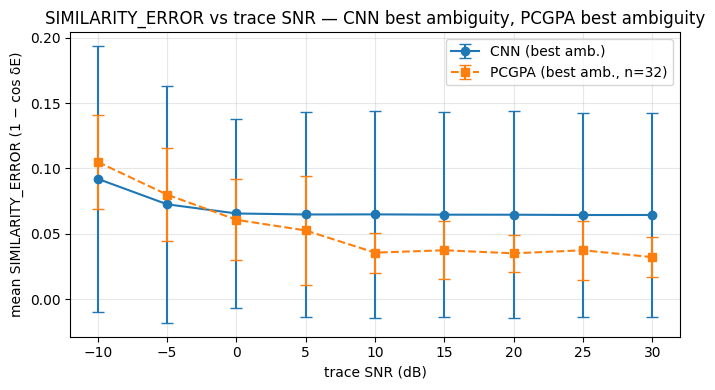

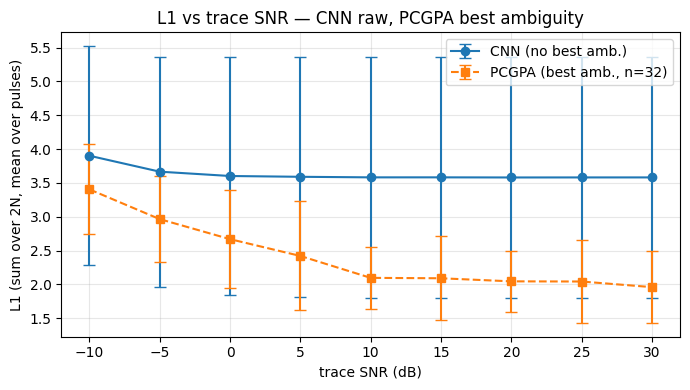

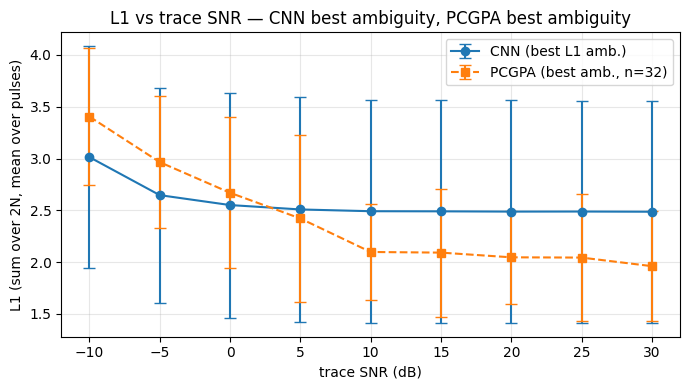

SNR (dB) -> equivalent N: [(np.float64(-10.0), np.float64(640.0)), (np.float64(-5.0), np.float64(2023.86)), (np.float64(0.0), np.float64(6400.0)), (np.float64(5.0), np.float64(20238.58)), (np.float64(10.0), np.float64(64000.0)), (np.float64(15.0), np.float64(202385.77)), (np.float64(20.0), np.float64(640000.0)), (np.float64(25.0), np.float64(2023857.7)), (np.float64(30.0), np.float64(6400000.0))]


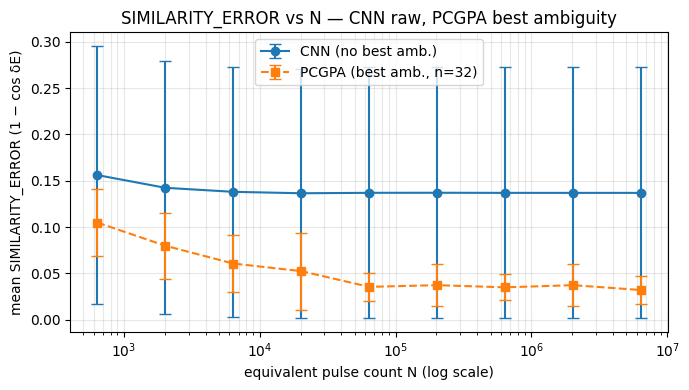

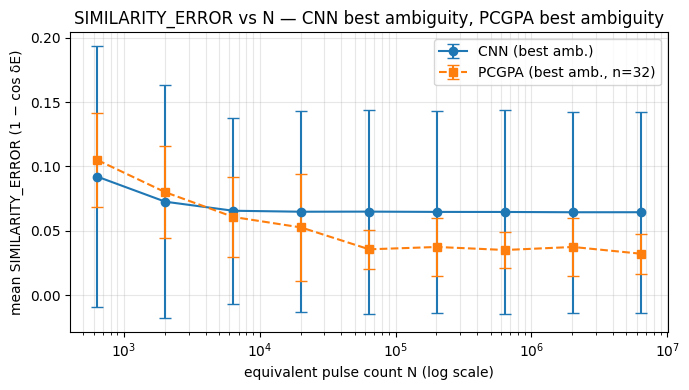

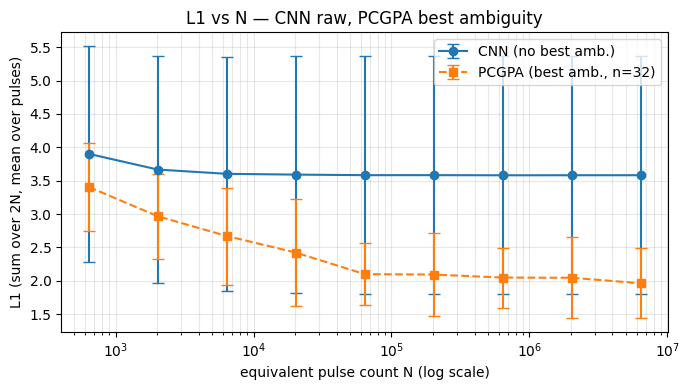

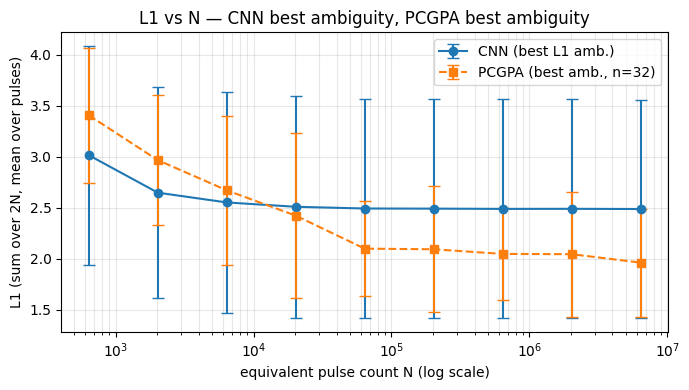

In [11]:
from pulse_metrics import (
    best_l1_ambiguity,
    best_similarity_error_ambiguity,
    l1_packed_mae,
    packed_batch_to_complex,
    similarity_error_numpy,
    snr_db_to_equivalent_n_pulses,
)


def mean_metric_cnn_at_snr(
    loader: DataLoader, snr_db: float, *, score_fn
) -> tuple[float, float]:
    model.eval()
    per: list[float] = []
    with torch.no_grad():
        for I_clean, E_true in loader:
            I_noisy = add_trace_noise(I_clean, snr_db)
            E_pred = model(I_noisy.unsqueeze(1))
            rec = packed_batch_to_complex(E_pred)
            true = packed_batch_to_complex(E_true)
            for i in range(rec.shape[0]):
                per.append(float(score_fn(rec[i], true[i])))
    arr = np.asarray(per, dtype=np.float64)
    return float(arr.mean()), float(arr.std(ddof=0))


def mean_l1_cnn_at_snr(
    loader: DataLoader, snr_db: float, *, score_fn, truth: str = "complex"
) -> tuple[float, float]:
    model.eval()
    per: list[float] = []
    with torch.no_grad():
        for I_clean, E_true in loader:
            I_noisy = add_trace_noise(I_clean, snr_db)
            E_pred = model(I_noisy.unsqueeze(1))
            rec = packed_batch_to_complex(E_pred)
            true_c = packed_batch_to_complex(E_true)
            for i in range(rec.shape[0]):
                ref = (
                    E_true[i].cpu().numpy()
                    if truth == "packed"
                    else true_c[i]
                )
                per.append(float(score_fn(rec[i], ref)))
    arr = np.asarray(per, dtype=np.float64)
    return float(arr.mean()), float(arr.std(ddof=0))


import pcgpa_reconstruct

from pathlib import Path

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **kwargs):
        return x

_pcgpa = pcgpa_reconstruct.reload_from_disk()
mean_metrics_at_snr_pcgpa = _pcgpa.mean_metrics_at_snr_pcgpa
if getattr(_pcgpa, "PCGPA_API_VERSION", 0) < 5:
    raise RuntimeError(
        f"Stale pcgpa at {_pcgpa.__file__} (API v{getattr(_pcgpa, 'PCGPA_API_VERSION', '?')}); "
        "restart kernel and re-run smoke cell"
    )

_i_test_np = I_test.cpu().numpy()
_e_test_np = E_test.cpu().numpy()

_pcgpa_kw = dict(
    add_noise_fn=add_trace_noise,
    dt=DT,
    sigma_omega=SIGMA_OMEGA,
    maxiter=PCGPA_MAXITER,
    n_subsample=PCGPA_N_TEST,
    n_restarts=PCGPA_N_RESTARTS,
    seed=SEED,
)


def _plot_metric_curves(
    x,
    series: list[tuple[list[float], list[float], str, str]],
    *,
    xlabel: str,
    ylabel: str,
    title: str,
    xscale: str | None = None,
) -> None:
    plt.figure(figsize=(7, 4))
    for mean, std, fmt, label in series:
        plt.errorbar(x, mean, yerr=std, fmt=fmt, label=label, capsize=4)
    if xscale:
        plt.xscale(xscale)
        plt.grid(True, which="both", alpha=0.3)
    else:
        plt.grid(True, alpha=0.3)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# PCGPA: always best ambiguity. CNN similarity: raw vs best ambiguity.
pcgpa_sim_m, pcgpa_sim_s = [], []
pcgpa_l1_m, pcgpa_l1_s = [], []
cnn_sim_raw_m, cnn_sim_raw_s = [], []
cnn_sim_amb_m, cnn_sim_amb_s = [], []
cnn_l1_raw_m, cnn_l1_raw_s = [], []
cnn_l1_amb_m, cnn_l1_amb_s = [], []

_cache_path = Path(PCGPA_SWEEP_CACHE)
_pcgpa_loaded = False
if RUN_PCGPA_SWEEP and _cache_path.is_file() and not FORCE_RECOMPUTE_PCGPA:
    _z = np.load(_cache_path, allow_pickle=False)
    if np.array_equal(_z["snr_sweep_db"], SNR_SWEEP_DB):
        pcgpa_sim_m = list(_z["pcgpa_sim_m"])
        pcgpa_sim_s = list(_z["pcgpa_sim_s"])
        pcgpa_l1_m = list(_z["pcgpa_l1_m"])
        pcgpa_l1_s = list(_z["pcgpa_l1_s"])
        _pcgpa_loaded = True
        print(f"Loaded PCGPA sweep from {_cache_path}")

print(
    f"Sweep — PCGPA n={PCGPA_N_TEST} (always best amb.), "
    f"CNN n={N_TEST} (raw vs best amb.)"
)
if RUN_PCGPA_SWEEP and not _pcgpa_loaded:
    _n_pcgpa = len(SNR_SWEEP_DB) * PCGPA_N_TEST
    print(
        f"PCGPA: {_n_pcgpa} reconstructions "
        f"({len(SNR_SWEEP_DB)} SNR × {PCGPA_N_TEST} pulses, "
        f"maxiter={PCGPA_MAXITER}, restarts={PCGPA_N_RESTARTS}) — may take a long time on CPU"
    )
elif not RUN_PCGPA_SWEEP:
    print("RUN_PCGPA_SWEEP=False — skipping PCGPA (plots need cached curves or manual fill)")

for snr_db in tqdm(SNR_SWEEP_DB, desc="SNR sweep"):
    if RUN_PCGPA_SWEEP and not _pcgpa_loaded:
        (sm, ss), (lm, ls) = mean_metrics_at_snr_pcgpa(
            _i_test_np,
            _e_test_np,
            float(snr_db),
            use_best_ambiguity=True,
            show_progress=True,
            **_pcgpa_kw,
        )
        pcgpa_sim_m.append(sm)
        pcgpa_sim_s.append(ss)
        pcgpa_l1_m.append(lm)
        pcgpa_l1_s.append(ls)

    m, s = mean_metric_cnn_at_snr(
        test_loader, float(snr_db), score_fn=similarity_error_numpy
    )
    cnn_sim_raw_m.append(m)
    cnn_sim_raw_s.append(s)
    m, s = mean_metric_cnn_at_snr(
        test_loader, float(snr_db), score_fn=best_similarity_error_ambiguity
    )
    cnn_sim_amb_m.append(m)
    cnn_sim_amb_s.append(s)

    m, s = mean_l1_cnn_at_snr(
        test_loader,
        float(snr_db),
        score_fn=lambda rec, packed: l1_packed_mae(
            rec, packed, use_best_ambiguity=False
        ),
        truth="packed",
    )
    cnn_l1_raw_m.append(m)
    cnn_l1_raw_s.append(s)
    m, s = mean_l1_cnn_at_snr(
        test_loader, float(snr_db), score_fn=best_l1_ambiguity
    )
    cnn_l1_amb_m.append(m)
    cnn_l1_amb_s.append(s)

if RUN_PCGPA_SWEEP and not _pcgpa_loaded:
    _cache_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez(
        _cache_path,
        snr_sweep_db=SNR_SWEEP_DB,
        pcgpa_sim_m=np.asarray(pcgpa_sim_m),
        pcgpa_sim_s=np.asarray(pcgpa_sim_s),
        pcgpa_l1_m=np.asarray(pcgpa_l1_m),
        pcgpa_l1_s=np.asarray(pcgpa_l1_s),
        pcgpa_n_test=PCGPA_N_TEST,
        pcgpa_maxiter=PCGPA_MAXITER,
        pcgpa_n_restarts=PCGPA_N_RESTARTS,
    )
    print(f"Saved PCGPA sweep to {_cache_path}")

cnn_sim_max_diff = max(abs(a - b) for a, b in zip(cnn_sim_raw_m, cnn_sim_amb_m))
cnn_l1_max_diff = max(abs(a - b) for a, b in zip(cnn_l1_raw_m, cnn_l1_amb_m))
print(
    f"CNN SIMILARITY_ERROR: max |mean(raw) − mean(amb)| over SNR = {cnn_sim_max_diff:.6f}"
)
print(f"CNN L1: max |mean(raw) − mean(amb)| over SNR = {cnn_l1_max_diff:.6f}")

_pcgpa_lbl = f"PCGPA (best amb., n={PCGPA_N_TEST})"
_sim_ylabel = "mean SIMILARITY_ERROR (1 − cos δE)"

# --- (2) SIMILARITY_ERROR vs trace SNR (four plots, same layout as former δE pair + L1 pair) ---
_plot_metric_curves(
    SNR_SWEEP_DB,
    [
        (cnn_sim_raw_m, cnn_sim_raw_s, "-o", "CNN (no best amb.)"),
        (pcgpa_sim_m, pcgpa_sim_s, "--s", _pcgpa_lbl),
    ],
    xlabel="trace SNR (dB)",
    ylabel=_sim_ylabel,
    title="SIMILARITY_ERROR vs trace SNR — CNN raw, PCGPA best ambiguity",
)

_plot_metric_curves(
    SNR_SWEEP_DB,
    [
        (cnn_sim_amb_m, cnn_sim_amb_s, "-o", "CNN (best amb.)"),
        (pcgpa_sim_m, pcgpa_sim_s, "--s", _pcgpa_lbl),
    ],
    xlabel="trace SNR (dB)",
    ylabel=_sim_ylabel,
    title="SIMILARITY_ERROR vs trace SNR — CNN best ambiguity, PCGPA best ambiguity",
)

_plot_metric_curves(
    SNR_SWEEP_DB,
    [
        (cnn_l1_raw_m, cnn_l1_raw_s, "-o", "CNN (no best amb.)"),
        (pcgpa_l1_m, pcgpa_l1_s, "--s", _pcgpa_lbl),
    ],
    xlabel="trace SNR (dB)",
    ylabel="L1 (sum over 2N, mean over pulses)",
    title="L1 vs trace SNR — CNN raw, PCGPA best ambiguity",
)

_plot_metric_curves(
    SNR_SWEEP_DB,
    [
        (cnn_l1_amb_m, cnn_l1_amb_s, "-o", "CNN (best L1 amb.)"),
        (pcgpa_l1_m, pcgpa_l1_s, "--s", _pcgpa_lbl),
    ],
    xlabel="trace SNR (dB)",
    ylabel="L1 (sum over 2N, mean over pulses)",
    title="L1 vs trace SNR — CNN best ambiguity, PCGPA best ambiguity",
)

# --- (3) same four similarity/L1 sweeps vs equivalent pulse count N ---
N_equiv = np.array([snr_db_to_equivalent_n_pulses(float(s)) for s in SNR_SWEEP_DB])
print("SNR (dB) -> equivalent N:", list(zip(SNR_SWEEP_DB, np.round(N_equiv, 2))))

_plot_metric_curves(
    N_equiv,
    [
        (cnn_sim_raw_m, cnn_sim_raw_s, "-o", "CNN (no best amb.)"),
        (pcgpa_sim_m, pcgpa_sim_s, "--s", _pcgpa_lbl),
    ],
    xlabel="equivalent pulse count N (log scale)",
    ylabel=_sim_ylabel,
    title="SIMILARITY_ERROR vs N — CNN raw, PCGPA best ambiguity",
    xscale="log",
)

_plot_metric_curves(
    N_equiv,
    [
        (cnn_sim_amb_m, cnn_sim_amb_s, "-o", "CNN (best amb.)"),
        (pcgpa_sim_m, pcgpa_sim_s, "--s", _pcgpa_lbl),
    ],
    xlabel="equivalent pulse count N (log scale)",
    ylabel=_sim_ylabel,
    title="SIMILARITY_ERROR vs N — CNN best ambiguity, PCGPA best ambiguity",
    xscale="log",
)

_plot_metric_curves(
    N_equiv,
    [
        (cnn_l1_raw_m, cnn_l1_raw_s, "-o", "CNN (no best amb.)"),
        (pcgpa_l1_m, pcgpa_l1_s, "--s", _pcgpa_lbl),
    ],
    xlabel="equivalent pulse count N (log scale)",
    ylabel="L1 (sum over 2N, mean over pulses)",
    title="L1 vs N — CNN raw, PCGPA best ambiguity",
    xscale="log",
)

_plot_metric_curves(
    N_equiv,
    [
        (cnn_l1_amb_m, cnn_l1_amb_s, "-o", "CNN (best L1 amb.)"),
        (pcgpa_l1_m, pcgpa_l1_s, "--s", _pcgpa_lbl),
    ],
    xlabel="equivalent pulse count N (log scale)",
    ylabel="L1 (sum over 2N, mean over pulses)",
    title="L1 vs N — CNN best ambiguity, PCGPA best ambiguity",
    xscale="log",
)